In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
## reading words
words = open('names.txt','r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
## creating characters vocabulary
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)

In [61]:
# build the dataset
block_size = 8 # context length: how many characters do we take to predict the next one?
def build_dataset(words):
    X, Y= [], []
    for w in words: 

        #print(w)
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            #print("'.join(itos[i] for i in context), '->', itos[ix])
            context = context[1:] + [ix] # crop and append

    X = torch. tensor(X)
    Y = torch. tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random. seed(42)
random. shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))
Xtr, Ytr = build_dataset(words[:n1])            ## 80% for training
Xdev, Ydev = build_dataset(words[n1:n2])        ## 10% for development/validation
Xte, Yte = build_dataset(words[n2:])            ## 10% for testing

torch.Size([182580, 8]) torch.Size([182580])
torch.Size([22767, 8]) torch.Size([22767])
torch.Size([22799, 8]) torch.Size([22799])


In [104]:
## summarizing everything by training deeper neural network
class Linear:
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5
        self.bias = torch.zeros(fan_out) if bias else None
    
    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])

class BatchNorm1d:
    def __init__(self, num_features,eps = 1e-5,momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        ## Parameter trained in backpropagation
        self.gamma = torch.ones(num_features)
        self.beta = torch.zeros(num_features)
        ## Parameter used in buffer
        self.running_mean = torch.zeros(num_features)
        self.running_var = torch.ones(num_features)
        self.training=True
    def __call__(self,x):
        if self.training:
            if x.ndim == 2:
                dim=0
            elif x.ndim == 3:
                dim = (0,1)
            xmean = x.mean(dim, keepdim=True)
            xvar = x.var(dim, keepdim=True) 
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x-xmean)/torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xhat + self.beta

        if self.training:
            ## update buffer
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out
    def parameters(self):
        return [self.gamma , self.beta]
class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    def parameters(self):
        return []

class Embedding:
    def __init__(self, num_embeddings, num_dims):
        self.weights = torch.randn((num_embeddings, num_dims))
    def __call__(self, x):
        self.out = self.weights[x]
        return self.out
    def parameters(self):
        return [self.weights]
# class Flatten:
#     def __call__(self, x):
#         self.out = x.view(x.shape[0],-1)
#         return self.out
#     def parameters(self)
class FlattenConsecutive:
    def __init__(self,n):
        self.n = n
    def __call__(self, x):
        B, T, C = x.shape
        x = x.view(B, T//self.n, C*self.n)
        if x.shape[1] == 1:
            x = x.squeeze(1)
        self.out = x
        return self.out
    def parameters(self):
        return []
class Sequential:
    def __init__(self, layers):
        self.layers = layers
    def __call__(self,x):
        for layer in self.layers:
            x = layer(x)
        self.out = x
        return self.out
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]


In [105]:
torch.manual_seed(42)

In [113]:
n_embed = 24
n_hidden = 128

model = Sequential([
Embedding(vocab_size, n_embed),
FlattenConsecutive(2),Linear(n_embed*2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
FlattenConsecutive(2),Linear(n_hidden*2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
FlattenConsecutive(2),Linear(n_hidden*2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
Linear(n_hidden, vocab_size)])

with torch.no_grad():
    layers[-1].weight *= 0.1 
parameters = model.parameters()

print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

76579


In [89]:
for layer in model.layers:
    print(layer.__class__.__name__, ':', tuple(layer.out.shape))

AttributeError: 'Embedding' object has no attribute 'out'

In [99]:
for i, layer in enumerate(model.layers):
    print(i, layer.__class__.__name__, hasattr(layer, 'out'))

0 Embedding False
1 FlattenConsecutive False
2 Linear False
3 BatchNorm1d False
4 Tanh False
5 FlattenConsecutive False
6 Linear False
7 BatchNorm1d False
8 Tanh False
9 FlattenConsecutive False
10 Linear False
11 BatchNorm1d False
12 Tanh False
13 Linear False


In [114]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix]  # batch X,Y

    # forward pass
    # emb = C[Xb]  # embed the characters into vectors
    # embcat = emb.view(emb.shape[0], -1)  # concatenate the vectors
    # embcat = Xb
    # for layer in layers:
    #     embcat = layer(embcat)
    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb)  # loss function

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 150000 else 0.01  # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad
    # track stats
    if i % 10000 == 0:  # print every once in a while
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    #if i >= 1000:
    #break ## we are chcking the first loss value and as we can see it is really high 27.881, now if all the characters should have a same probability of coming next then 
## initial loss should be 3.29 somthing as 1/27 so now we will try to decrease the initail loss

      0/ 200000: 3.5675
  10000/ 200000: 2.1474
  20000/ 200000: 2.2789
  30000/ 200000: 1.8496
  40000/ 200000: 2.1738
  50000/ 200000: 2.2974
  60000/ 200000: 1.5678
  70000/ 200000: 1.6755
  80000/ 200000: 1.9321
  90000/ 200000: 2.3766
 100000/ 200000: 2.1153
 110000/ 200000: 1.3853
 120000/ 200000: 2.3973
 130000/ 200000: 2.0351
 140000/ 200000: 1.6544
 150000/ 200000: 2.1581
 160000/ 200000: 1.5817
 170000/ 200000: 1.5643
 180000/ 200000: 2.1436
 190000/ 200000: 1.6803


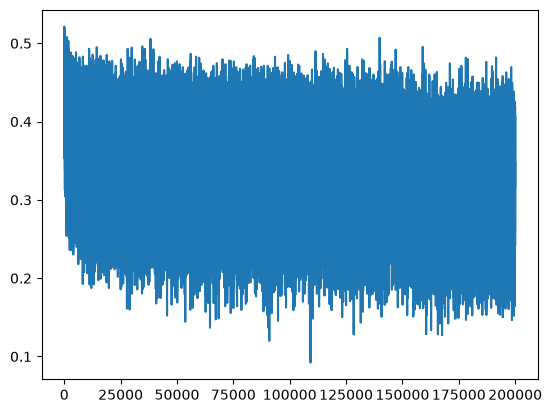

In [11]:
plt.plot(lossi)

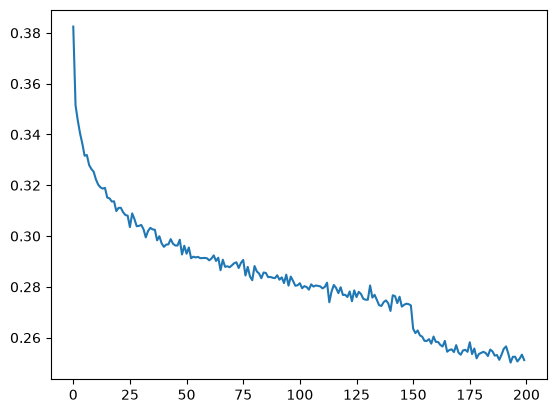

In [115]:
## Now we are fixing the above graph to make it more better and have a less breadth
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(dim=1))

In [116]:
## for eval mode, we need to set training in batchNorm for all the layer to false
for layer in model.layers:
    layer.training = False

In [117]:
@torch.no_grad()  # this decorator disables gradient tracking
def split_loss(split):
    x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
    }[split]
    # emb = C[x] # (N, block_size, n_embd)
    # embcat = emb. view(emb. shape[0], -1) # concat into (N, block_size *n_embd)
    # for layer in layers:
    #     embcat = layer(embcat)
    logits = model(x)
    loss = F.cross_entropy(logits, y)
    print (split, loss. item())
split_loss('train')
split_loss('val')

train 1.7687426805496216
val 1.9915812015533447


In [118]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):

    out = []
    context = [0] * block_size  # initialize with all ...

    while True:
        # forward pass the neural net
        # emb = C[torch.tensor([context])]  # (1, block_size, n_embd)
        # x = torch.tanh(emb.view(emb.shape[0], -1))
        # for layer in layers:
        #     x = layer(x)
        # logits = x
        logits = model(torch.tensor([context]))
        probs = F.softmax(logits, dim=1)
        # sample from the distribution
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()

        # shift the context window and track the samples
        context = context[1:] + [ix]
        out.append(ix)

        # if we sample the special '.' token, break
        if ix == 0:
            break

    print(''.join(itos[i] for i in out))  # decode and print the generated word

carmah.
amillie.
hirmari.
tatya.
kanson.
jazhun.
faresa.
chareei.
nelmari.
chaiim.
kaleigh.
hamson.
jaquint.
shlone.
liven.
corath.
gijarini.
jaxen.
dustine.
declin.


In [ ]:
## Now we can see the train and val loss are quite same means we are not over fitting it and we can work on the layer to improve loss, but even if we add more layer, we are
## still squashing everything in one layer, so we would need to think something else where we will have a tree like representation and can pass more characters then just three